<a href="https://colab.research.google.com/github/ChewWJ1/ML-dating-app-behaviour/blob/main/ML_dating_app_behaviour.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df=pd.read_csv('/content/drive/MyDrive/Dataset/dating_app_behavior_dataset.csv')

**Clean & Prepare the Data with Correct Column Names**

In [ ]:
print(len(df))

50000


In [ ]:
df.head() #print first 5 rows

,gender,sexual_orientation,location_type,income_bracket,education_level,interest_tags,app_usage_time_min,app_usage_time_label,swipe_right_ratio,swipe_right_label,likes_received,mutual_matches,profile_pics_count,bio_length,message_sent_count,emoji_usage_rate,last_active_hour,swipe_time_of_day,match_outcome
0,Prefer Not to Say,Gay,Urban,High,Bachelor’s,"Fitness, Politics, Traveling",52,Moderate,0.60,Optimistic,173,23,4,44,75,0.36,13,Early Morning,Mutual Match
1,Male,Bisexual,Suburban,Upper-Middle,No Formal Education,"Languages, Fashion, Parenting",279,Extreme User,0.56,Optimistic,107,7,3,301,35,0.42,0,Morning,Chat Ignored
2,Non-binary,Pansexual,Suburban,Low,Master’s,"Movies, Reading, DIY",49,Moderate,0.41,Optimistic,91,27,2,309,33,0.41,1,After Midnight,Date Happened
3,Genderfluid,Gay,Metro,Very Low,Postdoc,"Coding, Podcasts, History",185,Extreme User,0.32,Balanced,147,6,5,35,5,0.07,21,Morning,No Action
4,Male,Bisexual,Urban,Middle,Bachelor’s,"Clubbing, Podcasts, Cars",83,High,0.32,Balanced,94,11,1,343,34,0.11,22,After Midnight,One-sided Like


In [ ]:
print(df.columns)

Index(['gender', 'sexual_orientation', 'location_type', 'income_bracket',
       'education_level', 'interest_tags', 'app_usage_time_min',
       'app_usage_time_label', 'swipe_right_ratio', 'swipe_right_label',
       'likes_received', 'mutual_matches', 'profile_pics_count', 'bio_length',
       'message_sent_count', 'emoji_usage_rate', 'last_active_hour',
       'swipe_time_of_day', 'match_outcome'],
      dtype='object')


In [ ]:
df.columns = [
    'gender',
    'orientation',
    'location',
    'income',
    'education',
    'interests',
    'usage_time',
    'usage_category',
    'swipe_ratio',
    'swipe_behavior',
    'likes_received',
    'matches',
    'photo_count',
    'bio_length',
    'messages_sent',
    'emoji_rate',
    'active_hour',
    'swipe_time',
    'match_result'
]

In [ ]:
df.head()

,gender,orientation,location,income,education,interests,usage_time,usage_category,swipe_ratio,swipe_behavior,likes_received,matches,photo_count,bio_length,messages_sent,emoji_rate,active_hour,swipe_time,match_result
0,Prefer Not to Say,Gay,Urban,High,Bachelor’s,"Fitness, Politics, Traveling",52,Moderate,0.60,Optimistic,173,23,4,44,75,0.36,13,Early Morning,Mutual Match
1,Male,Bisexual,Suburban,Upper-Middle,No Formal Education,"Languages, Fashion, Parenting",279,Extreme User,0.56,Optimistic,107,7,3,301,35,0.42,0,Morning,Chat Ignored
2,Non-binary,Pansexual,Suburban,Low,Master’s,"Movies, Reading, DIY",49,Moderate,0.41,Optimistic,91,27,2,309,33,0.41,1,After Midnight,Date Happened
3,Genderfluid,Gay,Metro,Very Low,Postdoc,"Coding, Podcasts, History",185,Extreme User,0.32,Balanced,147,6,5,35,5,0.07,21,Morning,No Action
4,Male,Bisexual,Urban,Middle,Bachelor’s,"Clubbing, Podcasts, Cars",83,High,0.32,Balanced,94,11,1,343,34,0.11,22,After Midnight,One-sided Like


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   gender          50000 non-null  object 
 1   orientation     50000 non-null  object 
 2   location        50000 non-null  object 
 3   income          50000 non-null  object 
 4   education       50000 non-null  object 
 5   interests       50000 non-null  object 
 6   usage_time      50000 non-null  int64  
 7   usage_category  50000 non-null  object 
 8   swipe_ratio     50000 non-null  float64
 9   swipe_behavior  50000 non-null  object 
 10  likes_received  50000 non-null  int64  
 11  matches         50000 non-null  int64  
 12  photo_count     50000 non-null  int64  
 13  bio_length      50000 non-null  int64  
 14  messages_sent   50000 non-null  int64  
 15  emoji_rate      50000 non-null  float64
 16  active_hour     50000 non-null  int64  
 17  swipe_time      50000 non-null 

,usage_time,swipe_ratio,likes_received,matches,photo_count,bio_length,messages_sent,emoji_rate,active_hour
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.00000,50000.000000,50000.000000
mean,149.912400,0.500655,99.526040,13.870280,2.98772,250.174400,50.07194,0.286205,11.521800
std,86.990521,0.197468,57.996799,9.105615,1.99678,144.800996,29.16800,0.160042,6.920474
min,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000
25%,74.000000,0.370000,49.000000,6.000000,1.00000,125.000000,25.00000,0.160000,5.000000
50%,150.000000,0.500000,100.000000,13.000000,3.00000,250.000000,50.00000,0.270000,12.000000
75%,225.000000,0.640000,150.000000,22.000000,5.00000,376.000000,75.00000,0.390000,18.000000
max,300.000000,1.000000,200.000000,30.000000,6.00000,500.000000,100.00000,0.940000,23.000000


**Clean & Prepare the Dataset**


1.   Drop usage_category (e.g., "Moderate", "Extreme User"): You already have app_usage_time_min (e.g., 52, 185).
2.   Drop swipe_behavior (e.g., "Optimistic", "Balanced"): You already have swipe_right_ratio (e.g., 0.60, 0.32).



In [ ]:
# List of columns to drop
columns_to_drop = [
    'usage_category',
    'swipe_behavior',
]

# Drop them from the dataframe
df = df.drop(columns=columns_to_drop)

# Look at your remaining, much cleaner feature set
print(df.columns.tolist())

['gender', 'orientation', 'location', 'income', 'education', 'interests', 'usage_time', 'swipe_ratio', 'likes_received', 'matches', 'photo_count', 'bio_length', 'messages_sent', 'emoji_rate', 'active_hour', 'swipe_time', 'match_result']


In [ ]:
df.head()

,gender,orientation,location,income,education,interests,usage_time,swipe_ratio,likes_received,matches,photo_count,bio_length,messages_sent,emoji_rate,active_hour,swipe_time,match_result
0,Prefer Not to Say,Gay,Urban,High,Bachelor’s,"Fitness, Politics, Traveling",52,0.60,173,23,4,44,75,0.36,13,Early Morning,Mutual Match
1,Male,Bisexual,Suburban,Upper-Middle,No Formal Education,"Languages, Fashion, Parenting",279,0.56,107,7,3,301,35,0.42,0,Morning,Chat Ignored
2,Non-binary,Pansexual,Suburban,Low,Master’s,"Movies, Reading, DIY",49,0.41,91,27,2,309,33,0.41,1,After Midnight,Date Happened
3,Genderfluid,Gay,Metro,Very Low,Postdoc,"Coding, Podcasts, History",185,0.32,147,6,5,35,5,0.07,21,Morning,No Action
4,Male,Bisexual,Urban,Middle,Bachelor’s,"Clubbing, Podcasts, Cars",83,0.32,94,11,1,343,34,0.11,22,After Midnight,One-sided Like


In [ ]:
df.isna().sum()

,0
gender,0
orientation,0
location,0
income,0
education,0
interests,0
usage_time,0
swipe_ratio,0
likes_received,0
matches,0


In [ ]:
df.duplicated().sum()

np.int64(0)

*gender*

In [ ]:
df['gender'].value_counts()

,count
gender,
Female,8384
Non-binary,8366
Transgender,8353
Prefer Not to Say,8335
Genderfluid,8307
Male,8255


*orientation*

In [ ]:
df['orientation'].value_counts()

,count
orientation,
Straight,6326
Lesbian,6315
Demisexual,6301
Queer,6288
Asexual,6254
Pansexual,6237
Bisexual,6158
Gay,6121


*income*
*   Categorize income to low, middle and high categories only











In [ ]:
df['income'].value_counts()

,count
income,
High,7309
Very High,7178
Low,7132
Middle,7126
Lower-Middle,7118
Upper-Middle,7076
Very Low,7061


In [ ]:
df['income'] = df['income'].replace({
    'Very Low': 'Low',
    'Low': 'Low',
    'Lower-Middle': 'Middle',
    'Middle': 'Middle',
    'Upper-Middle': 'Middle',
    'High': 'High',
    'Very High': 'High'
})

In [ ]:
df['income'].value_counts()

,count
income,
Middle,21320
High,14487
Low,14193


*education*

In [ ]:
df['education'].value_counts()

,count
education,
Bachelor’s,5646
MBA,5637
High School,5632
PhD,5594
No Formal Education,5569
Master’s,5503
Associate’s,5499
Postdoc,5473
Diploma,5447


In [ ]:
df['education'] = df['education'].replace({
    'No Formal Education': 'Low',
    'High School': 'Low',
    'Diploma': 'Low',

    'Associate’s': 'Middle',
    'Bachelor’s': 'Middle',

    'Master’s': 'High',
    'MBA': 'High',
    'PhD': 'High',
    'Postdoc': 'High'
})

In [ ]:
df['education'].value_counts()

,count
education,
High,22207
Low,16648
Middle,11145


*match_result*

In [ ]:
df['match_result'].value_counts()

,count
match_result,
One-sided Like,5112
Instant Match,5078
Blocked,5049
Catfished,5025
Chat Ignored,5019
Mutual Match,4990
No Action,4986
Ghosted,4959
Date Happened,4919


*usage_time*
*   The usage_time was normalized using StandardScaler so that it has mean 0 and standard deviation 1, as required for many ML algorithms.







In [ ]:
df['usage_time'].value_counts()

,count
usage_time,
293,208
71,207
111,207
292,206
117,194
...,...
92,141
124,140
160,137


In [ ]:
# Check for missing values
df.fillna({'usage_time': df['usage_time'].median()}, inplace=True)

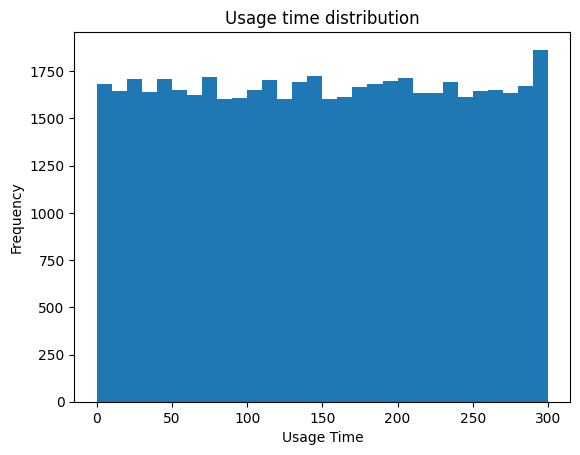

In [ ]:
# Look for Outliers
import matplotlib.pyplot as plt
plt.hist(df['usage_time'], bins=30)
plt.title('Usage time distribution')
plt.xlabel('Usage Time')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# Normalize the values
from sklearn.preprocessing import StandardScaler
df['usage_time'] = StandardScaler().fit_transform(df[['usage_time']])

In [ ]:
df['usage_time'].value_counts()

,count
usage_time,
1.644881,208
-0.907147,207
-0.447322,207
1.633385,206
-0.378348,194
...,...
-0.665739,141
-0.297879,140
0.115963,137


*swipe_ratio*
*  The swipe_ratio column, which ranges from 0 to 1, required no normalization as it already represents a ratio.No further transformation or encoding was performed at this stage.




In [ ]:
df['swipe_ratio'].value_counts()

,count
swipe_ratio,
0.53,1073
0.46,1035
0.49,1029
0.47,1012
0.52,1008
...,...
0.97,58
0.96,56
0.99,52


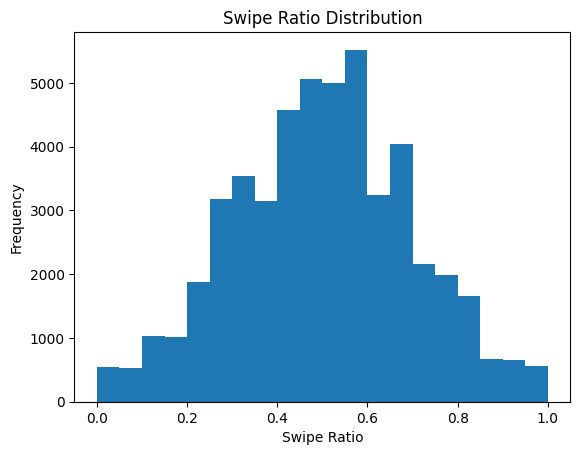

In [ ]:
import matplotlib.pyplot as plt
plt.hist(df['swipe_ratio'], bins=20)
plt.title('Swipe Ratio Distribution')
plt.xlabel('Swipe Ratio')
plt.ylabel('Frequency')
plt.show()

*likes_received*


*  The likes_received column, representing the count of likes each user received, was checked for missing values. No outlier treatment was performed as the distribution appeared reasonable. The values were normalized using StandardScaler to support subsequent machine learning steps.


In [ ]:
df['likes_received'].value_counts()

,count
likes_received,
40,287
48,283
126,280
114,279
159,278
...,...
63,223
120,221
140,220


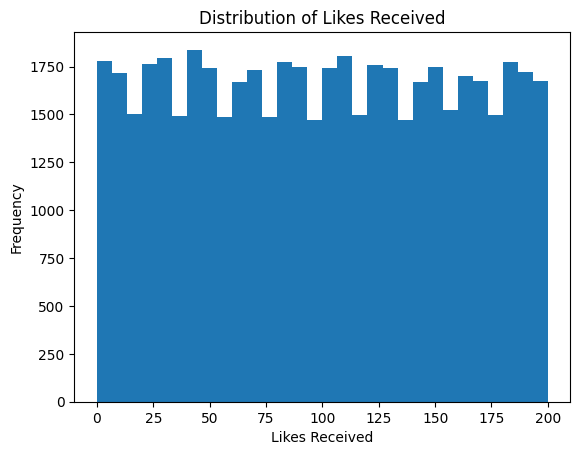

In [ ]:
import matplotlib.pyplot as plt
plt.hist(df['likes_received'], bins=30)
plt.xlabel('Likes Received')
plt.ylabel('Frequency')
plt.title('Distribution of Likes Received')
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
df['likes_received'] = StandardScaler().fit_transform(df[['likes_received']])

In [ ]:
df['likes_received'].value_counts()

,count
likes_received,
-1.026378,287
-0.888438,283
0.456477,280
0.249567,279
1.025480,278
...,...
-0.629800,223
0.353022,221
0.697872,220


*matches*

*   The matches column, representing the count of matches per user, was checked for missing values. The distribution was visualized and found to be plausible, with no implausible outliers. The values were then normalized using StandardScaler to ensure they are on a similar scale to other numeric features for machine learning



In [ ]:
df['matches'].value_counts()

,count
matches,
0,2382
1,2125
2,2040
3,1914
4,1861
5,1792
6,1709
7,1702
9,1663


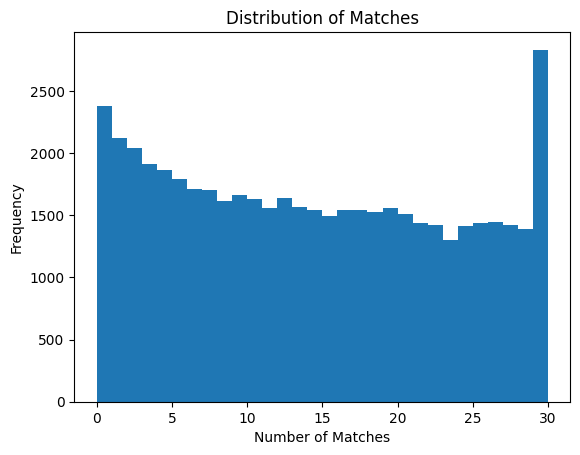

In [ ]:
import matplotlib.pyplot as plt
plt.hist(df['matches'], bins=30)
plt.xlabel('Number of Matches')
plt.ylabel('Frequency')
plt.title('Distribution of Matches')
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
df['matches'] = StandardScaler().fit_transform(df[['matches']])

In [ ]:
df['matches'].value_counts()

,count
matches,
-1.523282,2382
-1.413458,2125
-1.303635,2040
-1.193812,1914
-1.083988,1861
-0.974165,1792
-0.864341,1709
-0.754518,1702
-0.534871,1663


*photo_count*


*   The photo_count column, which records the number of photos added to a profile (range: 0–6), was checked for missing data. Given the reasonable value range, no outlier removal was needed. The values were normalized with StandardScaler for consistency with other numeric features.




In [ ]:
df['photo_count'].value_counts()

,count
photo_count,
2,7287
1,7171
0,7164
5,7161
4,7143
3,7060
6,7014


In [ ]:
from sklearn.preprocessing import StandardScaler
df['photo_count'] = StandardScaler().fit_transform(df[['photo_count']])

In [ ]:
df['photo_count'].value_counts()

,count
photo_count,
-0.494661,7287
-0.995473,7171
-1.496284,7164
1.007773,7161
0.506961,7143
0.006150,7060
1.508584,7014


*bio_length*

*  The bio_length column, representing the character count of each user's profile bio, was checked for missing values. The distribution was visualized and no extreme outliers were found. The data was standardized using StandardScaler to support model comparability.




In [ ]:
df['bio_length'].value_counts()

,count
bio_length,
189,134
31,128
401,126
448,123
194,123
...,...
323,76
364,76
272,76


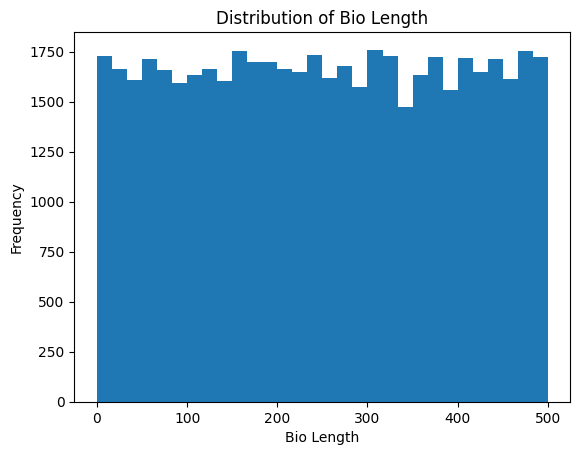

In [ ]:
import matplotlib.pyplot as plt
plt.hist(df['bio_length'], bins=30)
plt.xlabel('Bio Length')
plt.ylabel('Frequency')
plt.title('Distribution of Bio Length')
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
df['bio_length'] = StandardScaler().fit_transform(df[['bio_length']])

In [ ]:
df['bio_length'].value_counts()

,count
bio_length,
-0.422476,134
-1.513640,128
1.041617,126
1.366203,123
-0.387946,123
...,...
0.502941,76
0.786091,76
0.150730,76


*messages_sent*

*   The messages_sent column, representing the number of messages sent by each user, was checked for missing values. The distribution was visualized; no extreme outliers were found. The values were normalized with StandardScaler to conform with the scaling of other numeric features.



In [ ]:
df['messages_sent'].value_counts()

,count
messages_sent,
46,553
59,537
71,537
8,534
28,534
...,...
45,461
90,459
18,457


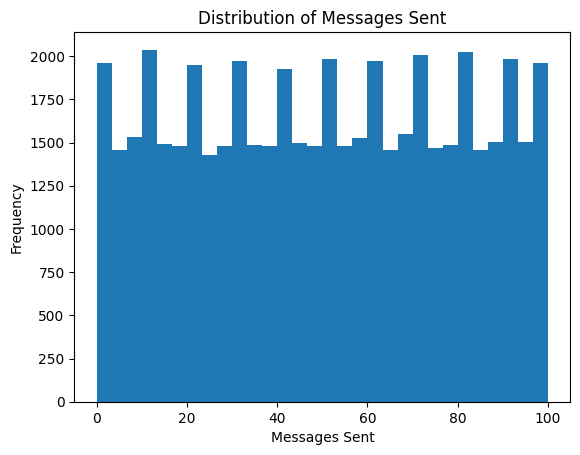

In [ ]:
import matplotlib.pyplot as plt
plt.hist(df['messages_sent'], bins=30)
plt.xlabel('Messages Sent')
plt.ylabel('Frequency')
plt.title('Distribution of Messages Sent')
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
df['messages_sent'] = StandardScaler().fit_transform(df[['messages_sent']])

In [ ]:
df['messages_sent'].value_counts()

,count
messages_sent,
-0.139604,553
0.306094,537
0.717508,537
-1.442415,534
-0.756725,534
...,...
-0.173889,461
1.368913,459
-1.099570,457


*emoji_rate*

*   The emoji_rate column, indicating the proportion of messages containing emojis, already fell in the [0, 1] range. No further transformation or normalization was applied.



In [ ]:
df['emoji_rate'].value_counts()

,count
emoji_rate,
0.19,1274
0.22,1268
0.20,1243
0.16,1227
0.21,1199
...,...
0.91,2
0.90,2
0.87,1


*active_hour*

*  The active_hour column, recording users' most active usage hour (0–23), was checked for missing values. All values were in-range. The column was normalized using StandardScaler.




In [ ]:
df['active_hour'].value_counts()

,count
active_hour,
3,2137
17,2137
23,2131
16,2130
18,2129
21,2128
5,2125
4,2118
8,2113


In [ ]:
from sklearn.preprocessing import StandardScaler
df['active_hour'] = StandardScaler().fit_transform(df[['active_hour']])

In [ ]:
df['active_hour'].value_counts()

,count
active_hour,
-1.231402,2137
0.791601,2137
1.658602,2131
0.647101,2130
0.936101,2129
1.369602,2128
-0.942401,2125
-1.086902,2118
-0.508901,2113


*swipe_time*

In [ ]:
df['swipe_time'].value_counts()

,count
swipe_time,
After Midnight,8524
Afternoon,8344
Early Morning,8320
Late Night,8287
Evening,8269
Morning,8256


*match_result*

*   The match_result column, which serves as the prediction target for the match success forecaster, was kept in the dataset but not used as a model feature. No encoding or transformation was applied at this stage; this will be handled later in the modeling process.



In [ ]:
df['match_result'].value_counts()

,count
match_result,
One-sided Like,5112
Instant Match,5078
Blocked,5049
Catfished,5025
Chat Ignored,5019
Mutual Match,4990
No Action,4986
Ghosted,4959
Date Happened,4919


In [ ]:
df['interests'].value_counts()

,count
interests,
"Fitness, Anime, Yoga",6
"Clubbing, Photography, Skating",5
"Languages, Painting, History",5
"Yoga, Astrology, Photography",5
"Crafting, Hiking, Social Activism",5
...,...
"Podcasts, Social Activism, Clubbing",1
"Startups, Art, Hiking",1
"Clubbing, MMA, Memes",1
